In [5]:
# Setup — run this cell first
%pip install openpyxl

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns


 

plt.rcParams['figure.dpi'] = 110

sns.set_theme(style='whitegrid')

 

print('Libraries loaded ✅')

 

 

#Section 1- Load the data set & inspect

df = pd.read_excel("taxis_data.xlsx", engine="openpyxl")

 

# See first rows

df.head()

 

# Check number of rows and columns (data size)

"Shape:", df.shape

 

# Show statistical summary of numerical columns

df.describe()

 


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [6]:
#Section2 - Clean & Prepare

 

# Create a copy so original data remains unchanged

df_clean = df.copy()

 

# Convert pickup and dropoff to datetime

df_clean["pickup"] = pd.to_datetime(df_clean["pickup"])

df_clean["dropoff"] = pd.to_datetime(df_clean["dropoff"])

df_clean.head()

 

# Remove invalid values

df_clean = df_clean[df_clean["distance"] > 0]

df_clean = df_clean[df_clean["fare"] > 0]

df_clean = df_clean[df_clean["passengers"] > 0]

df_clean.shape

 

# Create trip duration in minutes

df_clean["duration_min"] = (

    df_clean["dropoff"] - df_clean["pickup"]

).dt.total_seconds() / 60

 

df_clean.head()

 

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duration_min
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333


In [7]:
#Section 3 — Statistics

 

#Basic Stats

# Averages- pandas

"Average Fare (Pandas):", df_clean["fare"].mean()

"Average Distance (Pandas):", df_clean["distance"].mean()

"Average Tip (Pandas):", df_clean["tip"].mean()

 

#using numpy fetch Average fare and Max distance

"Average Fare (NumPy):", np.mean(df_clean["fare"])

"Max Distance (NumPy):", np.max(df_clean["distance"])

 

# Count payment types

df_clean["payment"].value_counts()

 

# Average total by borough- brough Analysis

df_clean.groupby("pickup_borough")["total"].mean()

 



pickup_borough
Bronx        22.275000
Brooklyn     19.219706
Manhattan    16.643932
Queens       32.129148
Name: total, dtype: float64

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15384\314862009.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


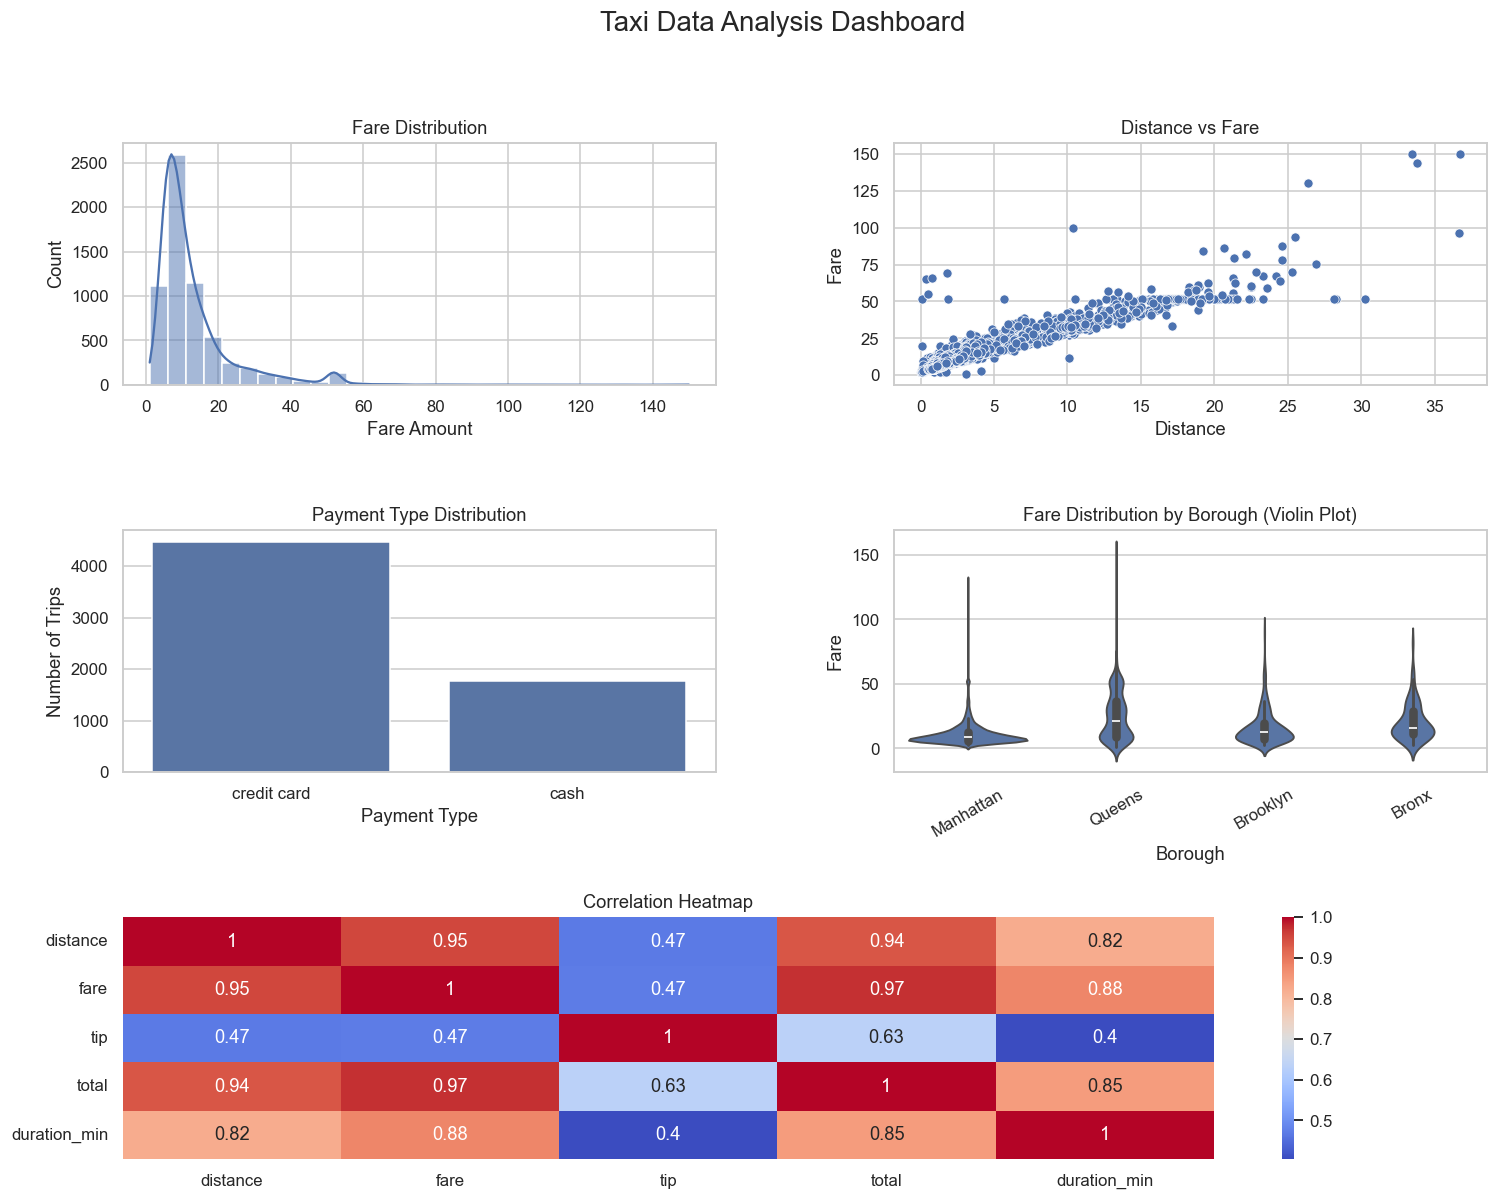

In [8]:
#Section 4— VISUALISE

 

# Create multi-panel dashboard

fig = plt.figure(figsize=(16, 12))

 

# Add spacing between rows and columns

gs = fig.add_gridspec(3, 2, hspace=0.6, wspace=0.3)

 

#Chart 1: Fare Distribution

ax1 = fig.add_subplot(gs[0, 0])

sns.histplot(df_clean["fare"], bins=30, kde=True, ax=ax1)

ax1.set_title("Fare Distribution")

ax1.set_xlabel("Fare Amount")

ax1.set_ylabel("Count")

 

#Chart 2: Distance vs Fare

ax2 = fig.add_subplot(gs[0, 1])

sns.scatterplot(x=df_clean["distance"], y=df_clean["fare"], ax=ax2)

ax2.set_title("Distance vs Fare")

ax2.set_xlabel("Distance")

ax2.set_ylabel("Fare")

 

# Chart 3: Payment Type

ax3 = fig.add_subplot(gs[1, 0])

sns.countplot(x="payment", data=df_clean, ax=ax3)

ax3.set_title("Payment Type Distribution")

ax3.set_xlabel("Payment Type")

ax3.set_ylabel("Number of Trips")

 

# Chart 4: Violin plot

ax4 = fig.add_subplot(gs[1, 1])

sns.violinplot(x="pickup_borough", y="fare", data=df_clean, ax=ax4)

ax4.set_title("Fare Distribution by Borough (Violin Plot)")

ax4.set_xlabel("Borough")

ax4.set_ylabel("Fare")

ax4.tick_params(axis='x', rotation=30)

 

# Heatmap

ax5 = fig.add_subplot(gs[2, :])  # span full row

corr = df_clean[["distance", "fare", "tip", "total", "duration_min"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax5)

ax5.set_title("Correlation Heatmap")

 

# Add dashboard title with proper spacing

fig.suptitle("Taxi Data Analysis Dashboard", fontsize=18)

 

# Adjust layout (prevents overlap with title)

plt.tight_layout(rect=[0, 0, 1, 0.95])

 

# Show dashboard

plt.show()

In [9]:
#Section 5 — KEY INSIGHTS

 

 #1. Most taxi trips are short distance as shown in the fare distribution histogram.

 

 #2. There is a strong positive relationship between distance and fare,

  #  meaning longer trips result in higher fares.

 

 #3. Credit card is the most preferred payment method compared to cash.

 

 #4. Taxi fares vary across boroughs, and some boroughs show wider fare distributions

  #  indicating presence of high-value trips.

 

 #5. Correlation heatmap shows strong relationships between:

   # - distance and fare

   # - fare and total amount

   # - duration and total fare

In [10]:
## Section 6 — Narrative Conclusion

 

# The taxi dataset analysis provides valuable insights into urban transportation patterns.  

# This line introduces the overall purpose of the project

 

# The results show that most trips are relatively short-distance journeys, indicating that taxis are primarily used for local travel within city areas.  

# Insight from histogram showing majority of low fare / short distance trips

 

# A clear positive relationship exists between trip distance and fare amount, confirming that fare pricing is directly influenced by the distance covered.  

# Insight from scatter plot (distance vs fare)

 

# Payment analysis reveals that credit cards are the most commonly used payment method, suggesting a preference for digital transactions among customers.  

# Insight from countplot (payment distribution)

 

# Further, borough-wise analysis highlights variations in fare distribution, with certain areas experiencing higher-value trips, likely due to longer distances such as airport routes.  

# Insight from violin plot (borough analysis)

 